In [2]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:


import sys 
from SF_functions import *
from Header_Binnings import *
from params import *
import numpy as np 
import glob
from astropy.table import Table
import astropy
# Enter path of object of interest, can also be specified as input



#original=sys.argv[1]


# In[2]:


objects_path = '/mnt/c/Users/20xha/Documents/Caltech/Research/superfit/spectra_nonan/'
objects_list = glob.glob(objects_path+'*.ascii') 


# In[3]:


sample = Table.read("/mnt/c/Users/20xha/Documents/Caltech/Research/superfit/ML_sample.ascii", format = "ascii")
sample.rename_column('col1', 'ZTF_Name')
sample.rename_column('col2', "Class")
sample.rename_column('col3', "redshift")
sample.rename_column('col8', "Version")


# In[5]:

missing = Table.read("/mnt/c/Users/20xha/Documents/GitHub/supernova-spectrum-analysis/ZooniverseAnalysis/missing.csv")

joined = astropy.table.join(missing, sample)


In [4]:
counter = 0
print(counter)

0


In [11]:
len(np.where(redshifts_all["ZTFID"] == row["ZTF_Name"])[0])

0

In [12]:
where = np.where(redshifts_all["ZTFID"] == row["ZTF_Name"])[0]
if(len(where) != 0):
    redshift_0 = redshifts_all.iloc[where]["redshift"].values[0]
    if(redshift_0 != '-'):
        redshift_0 = float(redshift_0)
        redshift = np.linspace(redshift_0 - 0.05 * redshift_0, redshift_0 + 0.05 * redshift_0, 3)

In [18]:
joined[50:]

Version,Resolution,Superfit_c,Superfit_z,ZTF_Name,Zooniverse_c,rlap,agreement,Class,redshift,col4,col5,col6,col7,col9
str43,int64,int64,int64,str12,str7,float64,float64,str12,float64,float64,float64,float64,float64,int64
ZTF18aaqeasu_20180517_P200_v2.ascii,--,--,--,ZTF18aaqeasu,Ia-csm,6.22,5.0,Ia-pec,0.04582,0.04582,2458255.5,2458260.7,-5.2,2
ZTF18aaqeasu_20180528_P60_v1.ascii,--,--,--,ZTF18aaqeasu,Ib-norm,5.29,3.0,Ia-pec,0.04582,0.04582,2458266.5,2458260.7,5.8,2
ZTF18aaqeasu_20180531_DCT_v1.ascii,--,--,--,ZTF18aaqeasu,Ic-BL,5.23,8.0,Ia-pec,0.04582,0.04582,2458269.5,2458260.7,8.8,2
ZTF18aaqeasu_20180608_P200_v2.ascii,--,--,--,ZTF18aaqeasu,Ic-BL,8.7,2.0,Ia-pec,0.04582,0.04582,2458277.5,2458260.7,16.8,2
ZTF18aaqeasu_20180617_Keck1_v1.ascii,--,--,--,ZTF18aaqeasu,LBV,7.8,5.0,Ia-pec,0.04582,0.04582,2458286.5,2458260.7,25.8,2
ZTF18aaqeasu_20180713_Keck1_v1.ascii,--,--,--,ZTF18aaqeasu,II-norm,12.31,2.0,Ia-pec,0.04582,0.04582,2458312.5,2458260.7,51.8,2
ZTF18aarvcmx_20180822_P60_v1.ascii,--,--,--,ZTF18aarvcmx,IIn,4.91,5.0,duplicate,0.0597,nan,2458352.5,2458350.6,1.9,0
ZTF18aarymnz_20180424_P60_v1.ascii,--,--,--,ZTF18aarymnz,Ia-norm,21.43,6.0,Ia,0.02356,0.02356,2458232.5,2458247.72,-15.22,2
ZTF18aasrssa_20180530_P60_v1.ascii,--,--,--,ZTF18aasrssa,Ia-norm,5.28,4.0,Ia,0.03089,0.03089,2458268.5,2458266.73,1.77,2


In [15]:
row = joined[52]
row

Version,Resolution,Superfit_c,Superfit_z,ZTF_Name,Zooniverse_c,rlap,agreement,Class,redshift,col4,col5,col6,col7,col9
str43,int64,int64,int64,str12,str7,float64,float64,str12,float64,float64,float64,float64,float64,int64
ZTF18aaqeasu_20180531_DCT_v1.ascii,--,--,--,ZTF18aaqeasu,Ic-BL,5.23,8.0,Ia-pec,0.04582,0.04582,2458269.5,2458260.7,8.8,2


Running optimization for spectrum file: ZTF18aaqeasu_20180531_DCT_v1_10A with resolution = 10 Ang
Optimization started


/home/hallflower/anaconda3/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:1266: RuntimeWarning: invalid value encountered in subtract
  return sc.xlogy(df/2.-1, x) - x/2. - sc.gammaln(df/2.) - (np.log(2)*df)/2.
/mnt/c/Users/20xha/Documents/Caltech/Research/superfit/superfit/SF_functions.py:384: RuntimeWarning: invalid value encountered in log
  lnprob = np.log(prob)


Optimization finished within  27.72s 


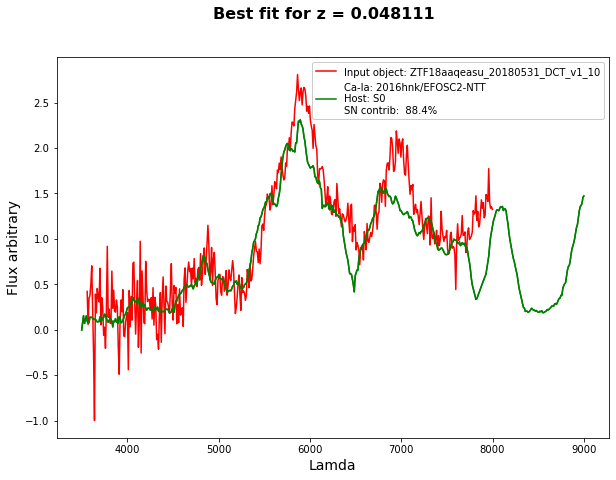

In [17]:
with open("parameters.json", "r") as read_file:
    data = json.load(read_file)


# Choose saving paths for binned data and results 

path = data['path']
sys.path.insert(1,path)
save_bin_path     = path + "bin/"
save_results_path = path + "results/"




# Path where original bank is located for metadata

original_bank_path = path + 'bank/original_resolution/sne/'

#--------------------------------------------------------------------------------------------------

# Select a range and number of steps for z

z_start  = data['z_start'] 
z_end    = data['z_end']
z_num    = data['z_num']



redshift      =    np.linspace(z_start, z_end,z_num)



# Number of steps for A_v (do not change)

alam_num = 21
extconstant   =    np.linspace(-2,2,alam_num)



# What part of the library do you want to look at?  

temp_gal_tr = data['temp_gal_tr']
temp_sn_tr  = data['temp_sn_tr']


# Select a wavelength range and resolution
resolution = data['resolution']
upper      = data['upper']
lower      = data['lower']
interval   = int((upper - lower)/resolution)
lam        =     np.linspace(lower, upper, interval)
# Kind of error spectrum ('SG', 'linear' or 'included')
kind = data['kind']
# To show plot? 
show = data['show']   
# How many top results to plot? 
n = data['n']

if (counter % 250 == 0):
    print("{} / {}".format(counter, len(sample)))
counter += 1

filename = row["Version"]
original = objects_path + filename
if(original in objects_list):
    n = 1
    resolution = data['resolution']
    upper      = data['upper']
    lower      = data['lower']

    maxmin_lambda = Table.read(original, format = "ascii")["col1"]
    min_lambda = min(maxmin_lambda)
    max_lambda = max(maxmin_lambda)

    if(upper < max_lambda):
        upper = max_lambda + 100
    if(lower > min_lambda):
        lower = min_lambda - 100

    interval   = int((upper - lower)/resolution)
    lam        =     np.linspace(lower, upper, interval)

    where = np.where(redshifts_all["ZTFID"] == row["ZTF_Name"])[0]
    first = False
    if(len(where) != 0):
        redshift_0 = redshifts_all.iloc[where]["redshift"].values[0]
        if(redshift_0 != '-'):
            redshift_0 = float(redshift_0)
            redshift = np.linspace(redshift_0 - 0.05 * redshift_0, redshift_0 + 0.05 * redshift_0, 3)
            first = True
    redshift_1 = row["redshift"]
    if(not(np.isnan(redshift_1)) and not(first)):
        redshift = np.linspace(redshift_1 - 0.05 * redshift_1, redshift_1 + 0.05 * redshift_1, 3)
    else:
        redshift = np.linspace(0, 0.2, 21)

    try:
        resolution=10
        binned_name= obj_name_int(original, lam, resolution)[3]
        print('Running optimization for spectrum file: {0} with resolution = {1} Ang'.format(binned_name,resolution))
        #Obtaining the binned file name (obj to be analyzed)
        save_bin = save_bin_path + binned_name
        #Calling the original file, getting rid of the header and binning it (default set to 20A)
        kill_header_and_bin(original,resolution, save_bin = save_bin)
        #Core superfit function on the binned file, default to plot and save n fits
        all_parameter_space(redshift,extconstant,templates_sn_trunc,templates_gal_trunc, 
        lam, resolution, n=n, plot=plotting, kind=kind, original=save_bin, save=save_results_path, show=show)
    except:
        try:
            resolution=20
            print('Failed. Retrying with resolution = {0} Ang'.format(resolution))

            #Obtaining the binned file name (obj to be analyzed)
            save_bin = save_bin_path + binned_name
            #Calling the original file, getting rid of the header and binning it (default set to 20A)
            kill_header_and_bin(original,resolution, save_bin = save_bin)
            #Core superfit function on the binned file, default to plot and save n fits
            all_parameter_space(redshift,extconstant,templates_sn_trunc,templates_gal_trunc, 
            lam, resolution, n=n, plot=plotting, kind=kind, original=save_bin, save=save_results_path, show=show)
        except:
            resolution=30
            print('Failed. Retrying with resolution = {0} Ang'.format(resolution))

            #Obtaining the binned file name (obj to be analyzed)
            try:
                save_bin = save_bin_path + binned_name
            except: 
                import ipdb; ipdb.set_trace()
            #Calling the original file, getting rid of the header and binning it (default set to 20A)
            kill_header_and_bin(original,resolution, save_bin = save_bin)
            #Core superfit function on the binned file, default to plot and save n fits
            all_parameter_space(redshift,extconstant,templates_sn_trunc,templates_gal_trunc, 
            lam, resolution, n=n, plot=plotting, kind=kind, original=save_bin, save=save_results_path, show=show)

In [ ]:
def new_params():
    with open("parameters.json", "r") as read_file:
        data = json.load(read_file)


    # Choose saving paths for binned data and results 

    path = data['path']
    sys.path.insert(1,path)
    save_bin_path     = path + "bin/"
    save_results_path = path + "results/"




    # Path where original bank is located for metadata

    original_bank_path = path + 'bank/original_resolution/sne/'

    #--------------------------------------------------------------------------------------------------

    # Select a range and number of steps for z

    z_start  = data['z_start'] 
    z_end    = data['z_end']
    z_num    = data['z_num']



    redshift      =    np.linspace(z_start, z_end,z_num)



    # Number of steps for A_v (do not change)

    alam_num = 21
    extconstant   =    np.linspace(-2,2,alam_num)



    # What part of the library do you want to look at?  

    temp_gal_tr = data['temp_gal_tr']
    temp_sn_tr  = data['temp_sn_tr']


    # Select a wavelength range and resolution
    resolution = data['resolution']
    upper      = data['upper']
    lower      = data['lower']
    interval   = int((upper - lower)/resolution)
    lam        =     np.linspace(lower, upper, interval)
    # Kind of error spectrum ('SG', 'linear' or 'included')
    kind = data['kind']
    # To show plot? 
    show = data['show']   
    # How many top results to plot? 
    n = data['n']

In [6]:
value = np.where(sample["Version"] == "ZTF20aaxhzhc_20200517_P60_v2.ascii")
print(str(value[0][0]) + "/" + str(len(sample)))

7295/8959


In [13]:
value[0][0]/len(sample)

0.22837370242214533

In [3]:
sample[820]

ZTF_Name,Class,redshift,col4,col5,col6,col7,Version,col9
str12,str12,float64,float64,float64,float64,float64,str43,int64
ZTF18abkjnqy,Ic,0.028,0.023522,2458336.5,2458346.62,-10.12,ZTF18abkjnqy_20180806_P60_v1.ascii,1


In [4]:
sample[820:]

ZTF_Name,Class,redshift,col4,col5,col6,col7,Version,col9
str12,str12,float64,float64,float64,float64,float64,str43,int64
ZTF18abkjnqy,Ic,0.028,0.023522,2458336.5,2458346.62,-10.12,ZTF18abkjnqy_20180806_P60_v1.ascii,1
ZTF18abkjnqy,Ic,0.028,0.023522,2458336.5,2458346.62,-10.12,ZTF18abkjnqy_20180806_P60_v2.ascii,1
ZTF18abkjnqy,Ic,0.028,0.023522,2458633.5,2458346.62,286.88,ZTF18abkjnqy_20190530_P60_v1.ascii,1
ZTF18abkjnqy,Ic,0.028,0.023522,2458633.5,2458346.62,286.88,ZTF18abkjnqy_20190530_P60_v2.ascii,1
ZTF18ablhvfr,Ia,0.088,nan,2458356.5,2458344.61,11.89,ZTF18ablhvfr_20180826_P60_v1.ascii,1
ZTF18ablqdru,-,0.02627,nan,2458345.5,2458364.59,-19.09,ZTF18ablqdru_20180815_P60_v1.ascii,0
ZTF18ablqdru,-,0.02627,nan,2458351.5,2458364.59,-13.09,ZTF18ablqdru_20180821_P200_v1.ascii,0
ZTF18ablqehq,IIn,0.03,0.030812,2458351.5,2458348.61,2.89,ZTF18ablqehq_20180821_P200_v1.ascii,1
ZTF18ablqlzp,Ia,0.036,0.0413,2458337.5,2458350.6,-13.1,ZTF18ablqlzp_20180807_P60_v1.ascii,1


In [23]:
counter = 0
row = sample[83]
with open("parameters.json", "r") as read_file:
    data = json.load(read_file)


# Choose saving paths for binned data and results 

path = data['path']
sys.path.insert(1,path)
save_bin_path     = path + "bin/"
save_results_path = path + "results/"




# Path where original bank is located for metadata

original_bank_path = path + 'bank/original_resolution/sne/'

#--------------------------------------------------------------------------------------------------

# Select a range and number of steps for z

z_start  = data['z_start'] 
z_end    = data['z_end']
z_num    = data['z_num']



redshift      =    np.linspace(z_start, z_end,z_num)



# Number of steps for A_v (do not change)

alam_num = 21
extconstant   =    np.linspace(-2,2,alam_num)



# What part of the library do you want to look at?  

temp_gal_tr = data['temp_gal_tr']
temp_sn_tr  = data['temp_sn_tr']


# Select a wavelength range and resolution
resolution = 20
upper      = data['upper']
lower      = data['lower']
interval   = int((upper - lower)/resolution)
lam        =     np.linspace(lower, upper, interval)
# Kind of error spectrum ('SG', 'linear' or 'included')
kind = data['kind']
# To show plot? 
show = data['show']   
# How many top results to plot? 
n = data['n']

if (counter % 250 == 0):
    print("{} / {}".format(counter, len(sample)))
counter += 1

filename = row["Version"]
original = objects_path + filename
if(original in objects_list):
    n = 3
    upper      = data['upper']
    lower      = data['lower']

    maxmin_lambda = Table.read(original, format = "ascii")["col1"]
    min_lambda = min(maxmin_lambda)
    max_lambda = max(maxmin_lambda)

    if(upper < max_lambda):
        upper = max_lambda + 100
    if(lower > min_lambda):
        lower = min_lambda - 100

    interval   = int((upper - lower)/resolution)
    lam        =     np.linspace(lower, upper, interval)

    redshift_0 = redshifts_all.iloc[np.where(redshifts_all["ZTFID"] == row["ZTF_Name"])[0]]["redshift"].values[0]
    redshift_1 = row["redshift"]
    if(redshift_0 != '-'):
        redshift_0 = float(redshift_0)
        redshift = np.linspace(redshift_0 - 0.05 * redshift_0, redshift_0 + 0.05 * redshift_0, 3)
    elif(not(np.isnan(redshift_1))):
        redshift = np.linspace(redshift_1 - 0.05 * redshift_1, redshift_1 + 0.05 * redshift_1, 3)
    else:
        redshift = np.linspace(0, 0.2, 21)

    try:
        resolution=20
        binned_name= obj_name_int(original, lam, resolution)[3]
        print('Running optimization for spectrum file: {0} with resolution = {1} Ang'.format(binned_name,resolution))
        #Obtaining the binned file name (obj to be analyzed)
        save_bin = save_bin_path + binned_name
        #Calling the original file, getting rid of the header and binning it (default set to 20A)
        kill_header_and_bin(original,resolution, save_bin = save_bin)
        #Core superfit function on the binned file, default to plot and save n fits
        all_parameter_space(redshift,extconstant,templates_sn_trunc,templates_gal_trunc, 
        lam, resolution, n=n, plot=plotting, kind=kind, original=save_bin, save=save_results_path, show=show)
    except:
        resolution=30
        print('Failed. Retrying with resolution = {0} Ang'.format(resolution))

        #Obtaining the binned file name (obj to be analyzed)
        try:
            save_bin = save_bin_path + binned_name
        except: 
            import ipdb; ipdb.set_trace()
        #Calling the original file, getting rid of the header and binning it (default set to 20A)
        kill_header_and_bin(original,resolution, save_bin = save_bin)
        #Core superfit function on the binned file, default to plot and save n fits
        all_parameter_space(redshift,extconstant,templates_sn_trunc,templates_gal_trunc, 
        lam, resolution, n=n, plot=plotting, kind=kind, original=save_bin, save=save_results_path, show=show)

0 / 8959
Running optimization for spectrum file: ZTF18aahqkbt_20180929_HST_v1_20A with resolution = 20 Ang
Optimization started
Failed. Retrying with resolution = 30 Ang
Optimization started


ValueError: If mode is 'interp', window_length must be less than or equal to the size of x.

In [3]:
sample[1]

ZTF_Name,Class,redshift,col4,col5,col6,col7,Version,col9
str12,str12,float64,float64,float64,float64,float64,str43,int64
ZTF18aabtxvd,TDE,0.071,nan,2458184.5,2458223.62,-39.12,ZTF18aabtxvd_20180307_P60_v1.ascii,0


In [26]:
print('An error has occured when trying to optimize for spectrum file {}. Inspect input spectrum and parameters. Stopping at {}'.format(binned_name, counter - 1))

An error has occured when trying to optimize for spectrum file ZTF18aahqkbt_20180929_HST_v1_20A. Inspect input spectrum and parameters. Stopping at 0
